In [24]:
import csv
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [25]:
data_dir = Path(".")   # change this if needed
csv_files = sorted(data_dir.glob("SIG*.csv"))

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f.name)

Found 17 CSV files:
SIG0029.csv
SIG0030.csv
SIG0031.csv
SIG0032.csv
SIG0033.csv
SIG0034.csv
SIG0035.csv
SIG0036.csv
SIG0037.csv
SIG0038.csv
SIG0039.csv
SIG0040.csv
SIG0041.csv
SIG0042.csv
SIG0043.csv
SIG0044.csv
SIG0045.csv


In [26]:
def to_float(x):
    x = x.strip()
    if x == "":
        return np.nan
    return float(x)

def parse_edm_csv(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.reader(f))
    
    rows = [[cell.strip() for cell in row] for row in rows]

    header_idx = None
    for i, row in enumerate(rows):
        if len(row) >= 11 and row[0].startswith("X(s)") and row[3].startswith("X(Hz)") and row[6].startswith("X(Hz)"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find numeric header row in {path.name}")

    data_rows = rows[header_idx + 1:]
    data_rows = [row + [""] * (11 - len(row)) if len(row) < 11 else row for row in data_rows]

    time = np.array([to_float(r[0]) for r in data_rows])
    force = np.array([to_float(r[1]) for r in data_rows])
    accel = np.array([to_float(r[2]) for r in data_rows])

    freq_aps = np.array([to_float(r[3]) for r in data_rows])
    aps_force = np.array([to_float(r[4]) for r in data_rows])
    aps_accel = np.array([to_float(r[5]) for r in data_rows])

    freq_frf = np.array([to_float(r[6]) for r in data_rows])
    frf_real = np.array([to_float(r[7]) for r in data_rows])
    frf_imag = np.array([to_float(r[8]) for r in data_rows])

    freq_coh = np.array([to_float(r[9]) for r in data_rows])
    coh = np.array([to_float(r[10]) for r in data_rows])

    frf_mag = np.sqrt(frf_real**2 + frf_imag**2)
    frf_phase_deg = np.degrees(np.arctan2(frf_imag, frf_real))

    m = re.search(r"SIG(\d+)", path.stem, re.IGNORECASE)
    sig_num = int(m.group(1)) if m else None

    return {
        "file": path.name,
        "sig_num": sig_num,
        "time": time,
        "force": force,
        "accel": accel,
        "freq_frf": freq_frf,
        "frf_real": frf_real,
        "frf_imag": frf_imag,
        "frf_mag": frf_mag,
        "frf_phase_deg": frf_phase_deg,
        "coherence": coh
    }

In [27]:
data = [parse_edm_csv(f) for f in csv_files]
data = sorted(data, key=lambda d: d["sig_num"])

print(f"Loaded {len(data)} files.")
print("First file:", data[0]["file"])
print("Last file:", data[-1]["file"])

Loaded 17 files.
First file: SIG0029.csv
Last file: SIG0045.csv


In [28]:
FREQ_MIN = 0
FREQ_MAX = 1800

def restrict_band(freq, *arrays, fmin=FREQ_MIN, fmax=FREQ_MAX):
    mask = np.isfinite(freq) & (freq >= fmin) & (freq <= fmax)
    out = [freq[mask]]
    for arr in arrays:
        out.append(arr[mask])
    return out

def hz_to_samples(freq, min_peak_distance_hz=80):
    df = np.median(np.diff(freq))
    return max(1, int(round(min_peak_distance_hz / df)))

### 1a

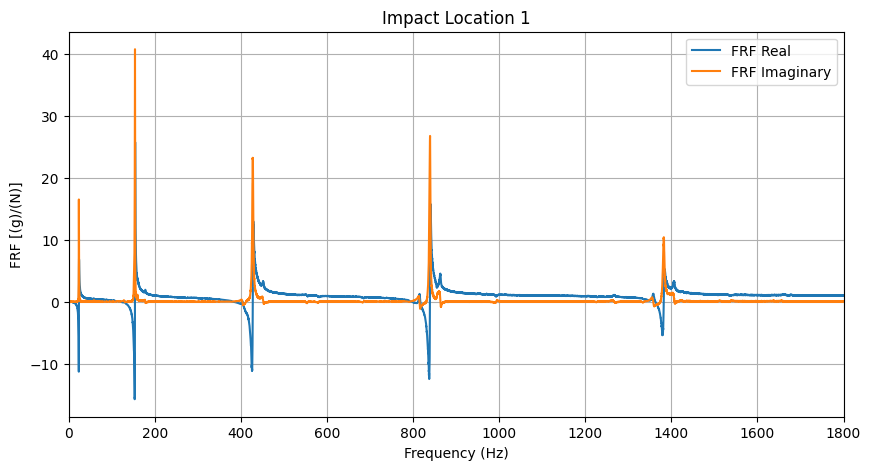

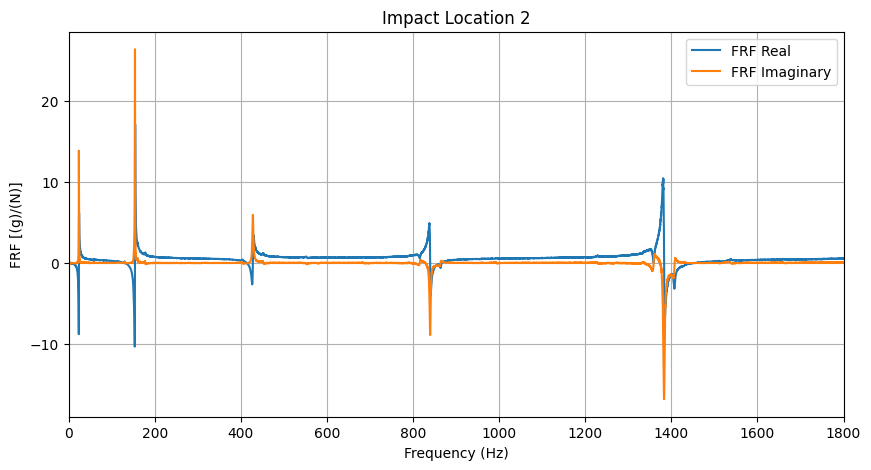

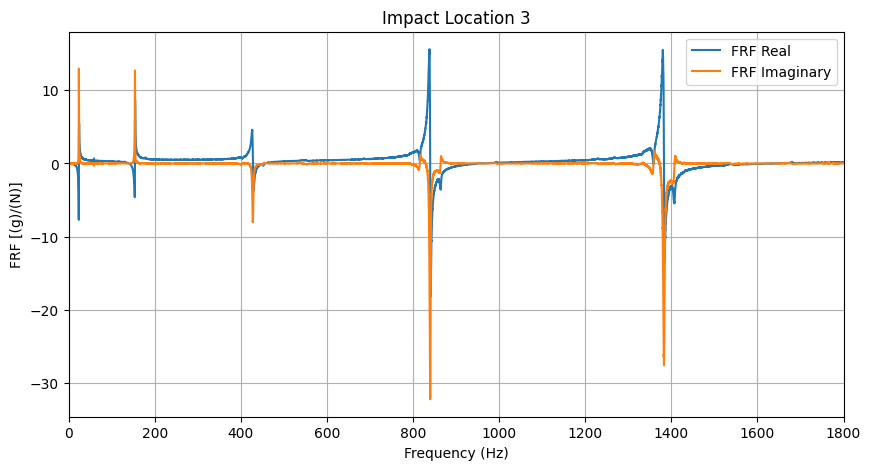

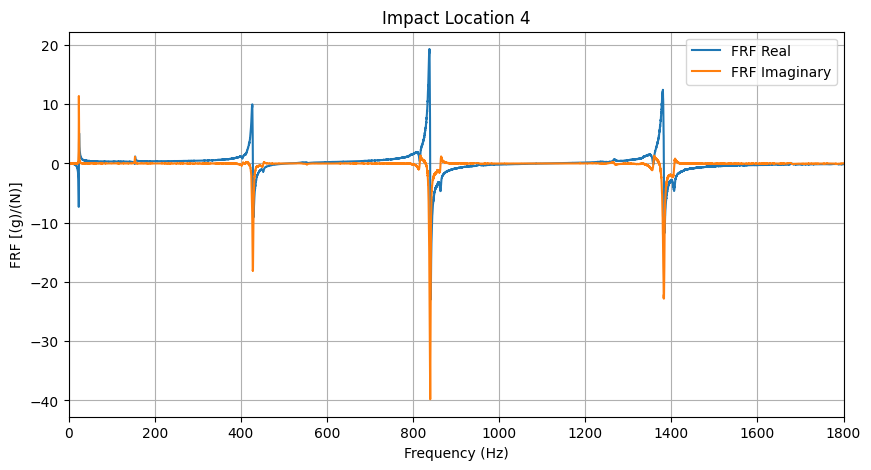

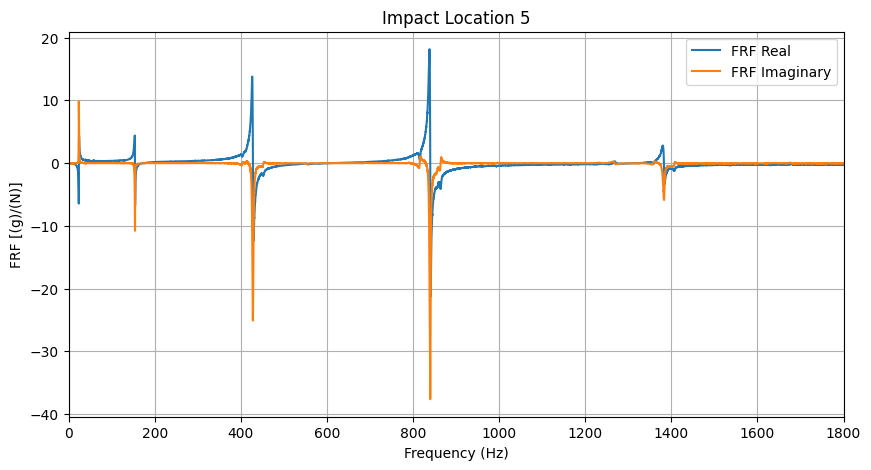

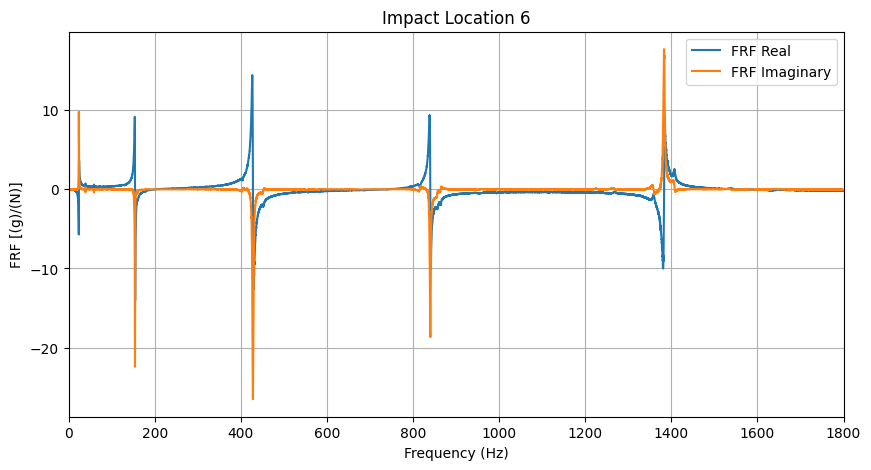

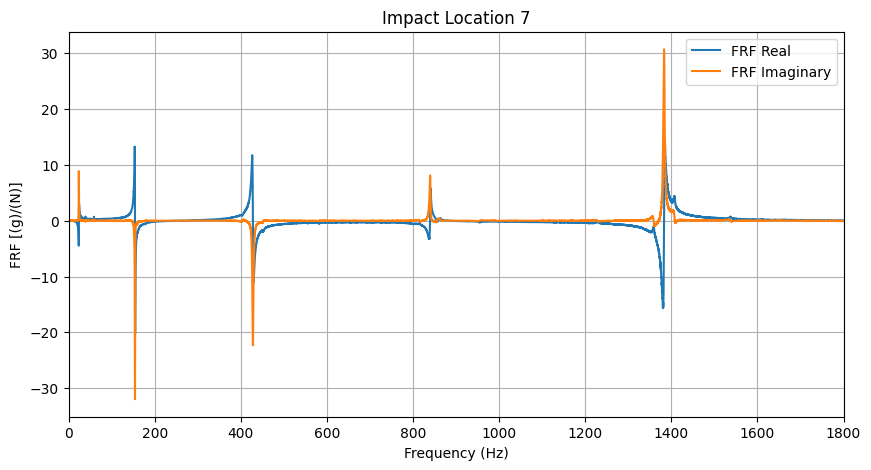

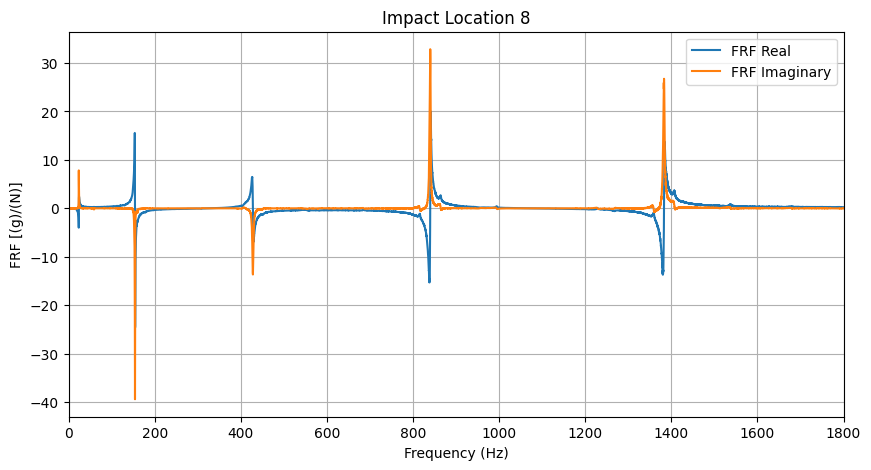

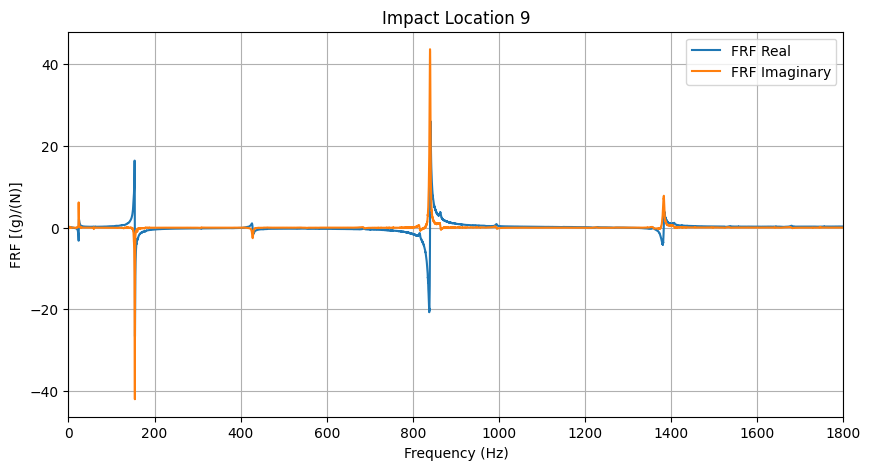

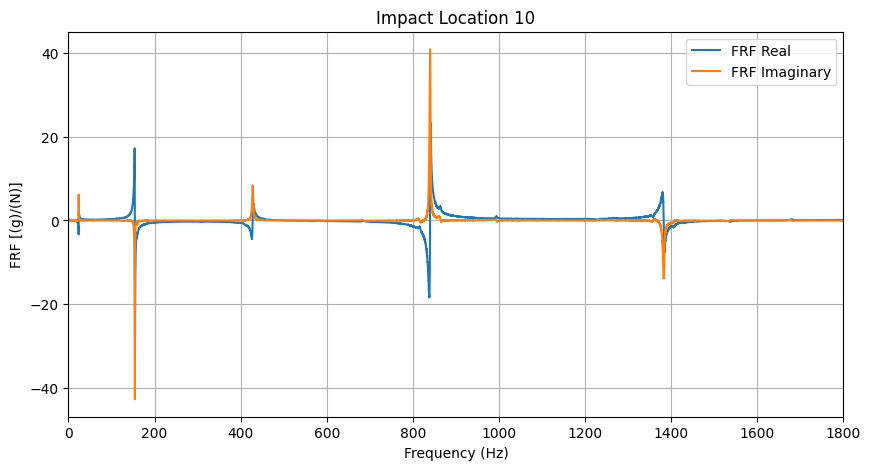

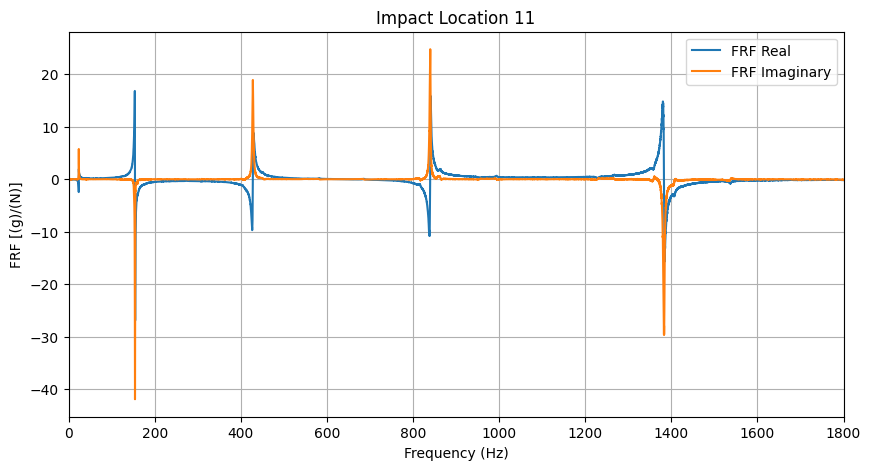

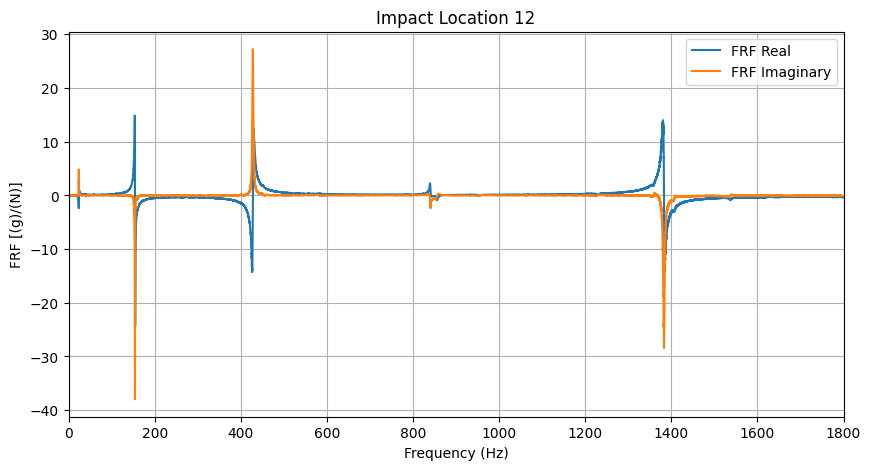

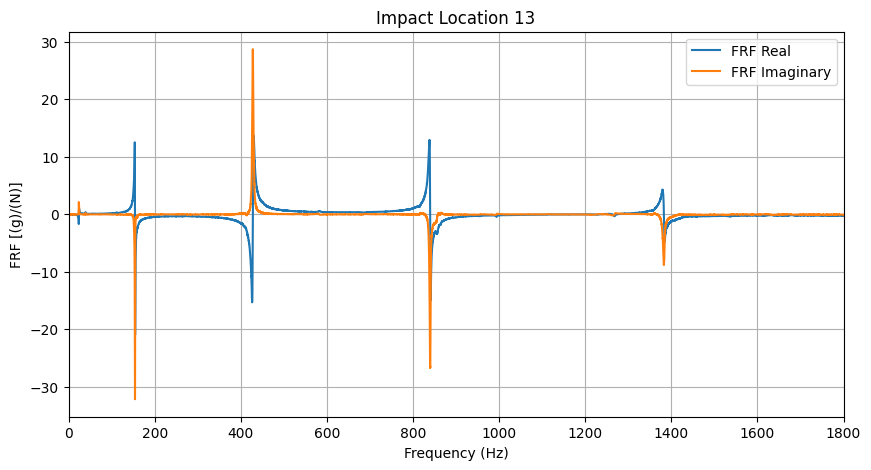

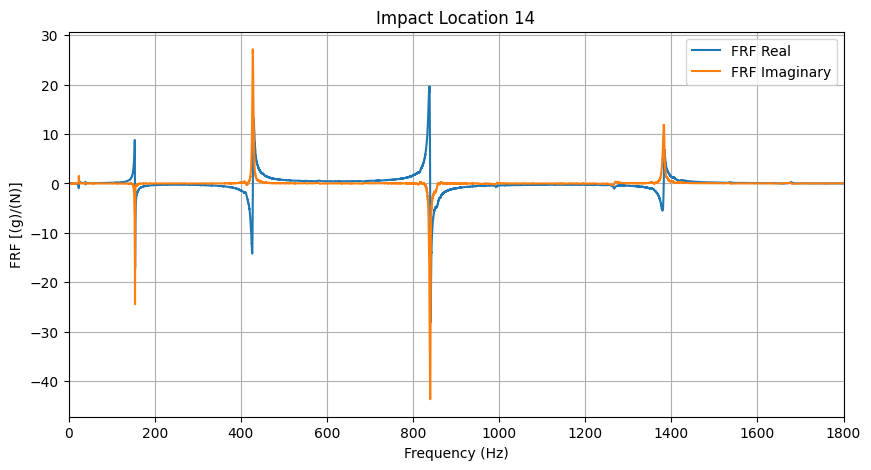

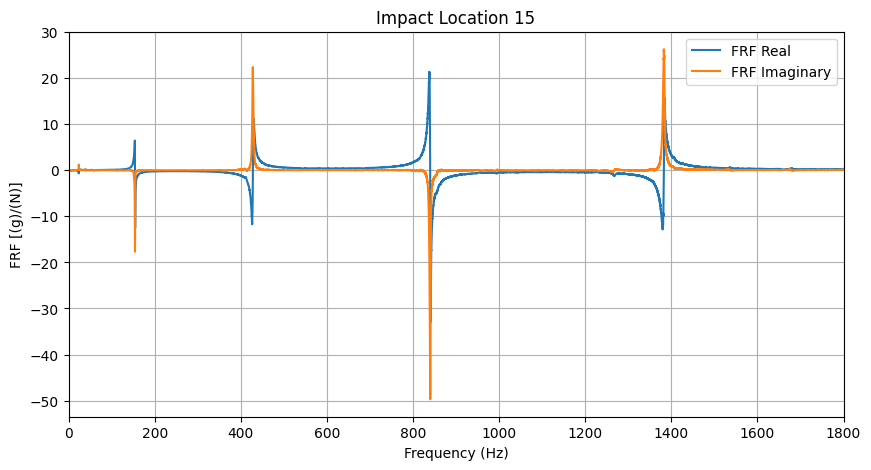

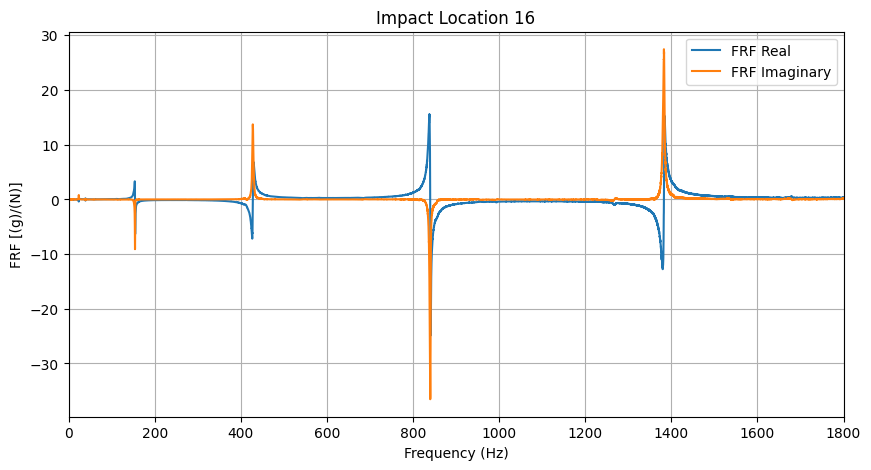

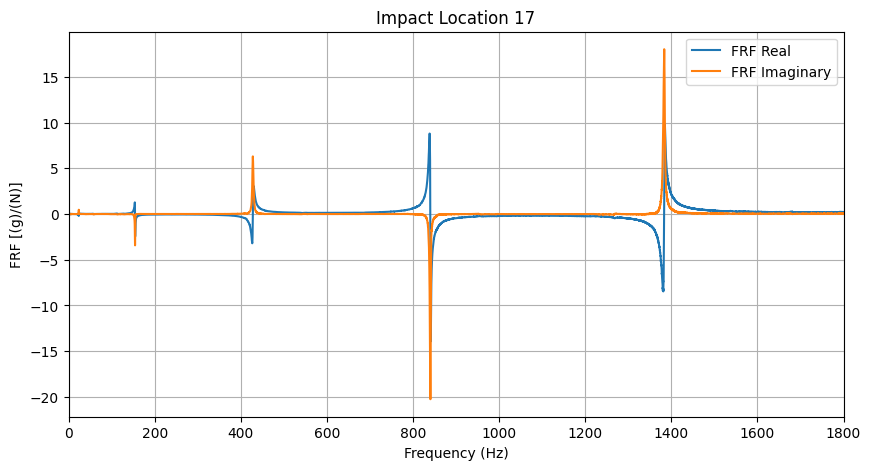

In [39]:
for i, d in enumerate(data, start=1):
    freq, real, imag = restrict_band(d["freq_frf"], d["frf_real"], d["frf_imag"])

    plt.figure(figsize=(10, 5))
    plt.plot(freq, real, label="FRF Real")
    plt.plot(freq, imag, label="FRF Imaginary")
    plt.xlim(FREQ_MIN, FREQ_MAX)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("FRF [(g)/(N)]")
    plt.title(f"Impact Location {i}")
    plt.legend()
    plt.show()

In [30]:
def imag_peak_real_zero_table(d, min_peak_distance_hz=80, imag_prom_frac=0.03, real_zero_tol_frac=0.05):
    freq, real, imag = restrict_band(d["freq_frf"], d["frf_real"], d["frf_imag"])

    distance = hz_to_samples(freq, min_peak_distance_hz)
    prominence = np.max(np.abs(imag)) * imag_prom_frac
    peaks, _ = find_peaks(np.abs(imag), prominence=prominence, distance=distance)

    real_tol = real_zero_tol_frac * np.max(np.abs(real))

    rows = []
    for p in peaks:
        if abs(real[p]) <= real_tol:
            rows.append({
                "frequency_hz": freq[p],
                "FRF_real": real[p],
                "FRF_imag": imag[p]
            })

    return pd.DataFrame(rows)

In [31]:
problem_1a_tables = []

for i, d in enumerate(data, start=1):
    df = imag_peak_real_zero_table(d)
    df.insert(0, "impact_location", i)
    df.insert(1, "file", d["file"])
    problem_1a_tables.append(df)

table_1a = pd.concat(problem_1a_tables, ignore_index=True)
table_1a

,impact_location,file,frequency_hz,FRF_real,FRF_imag
0,1,SIG0029.csv,24.000,0.712569,16.500763
1,1,SIG0029.csv,1382.625,1.075311,10.407640
2,2,SIG0030.csv,24.000,0.590284,13.831310
3,2,SIG0030.csv,428.250,0.575521,5.881359
4,2,SIG0030.csv,840.000,-0.163607,-8.871787
5,3,SIG0031.csv,24.000,0.700661,12.971129
6,3,SIG0031.csv,1383.000,0.258982,-27.587944
7,4,SIG0032.csv,24.000,0.387872,11.383556
8,5,SIG0033.csv,1383.125,-0.918086,-5.882810
9,6,SIG0034.csv,428.250,0.676595,-26.501640


In [32]:
table_1a.to_csv("problem_1a_imag_peaks_real_zero_table.csv", index=False)
print("Saved: problem_1a_imag_peaks_real_zero_table.csv")

Saved: problem_1a_imag_peaks_real_zero_table.csv


### 1b

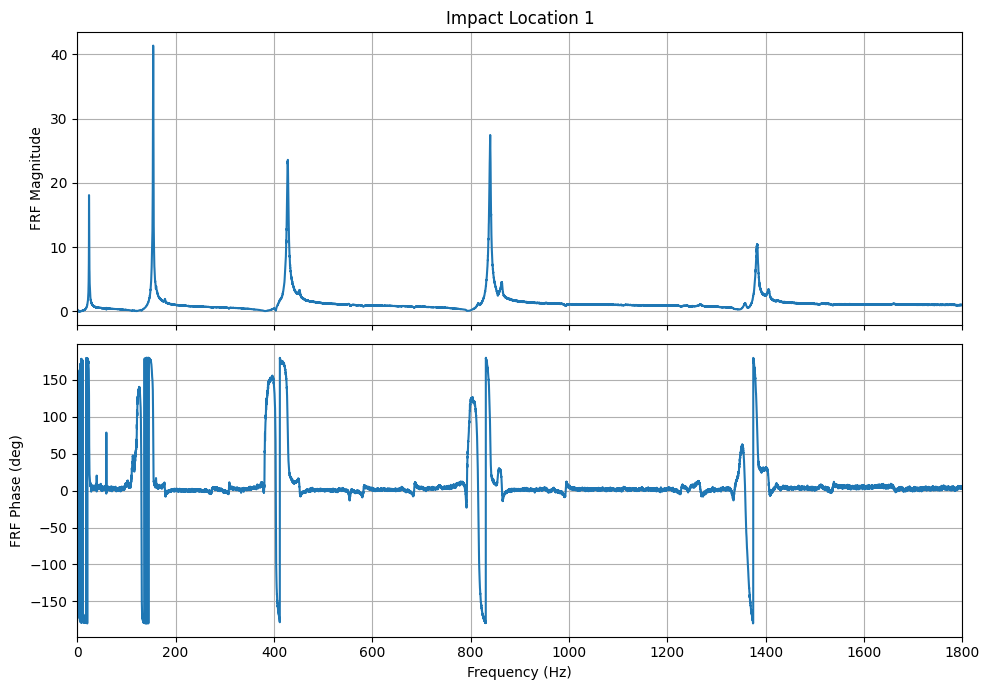

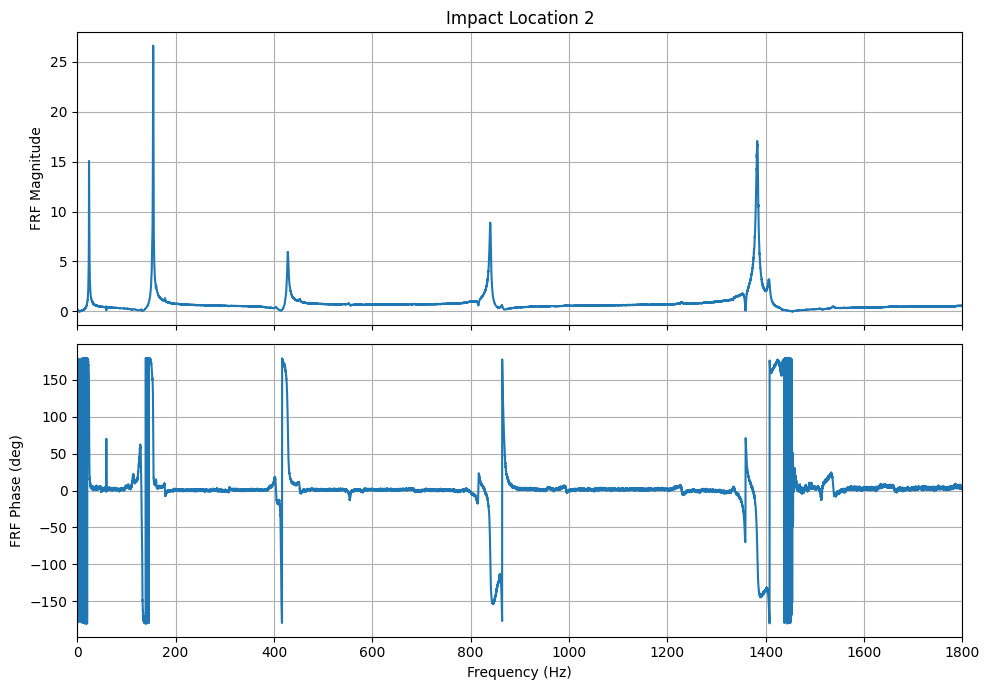

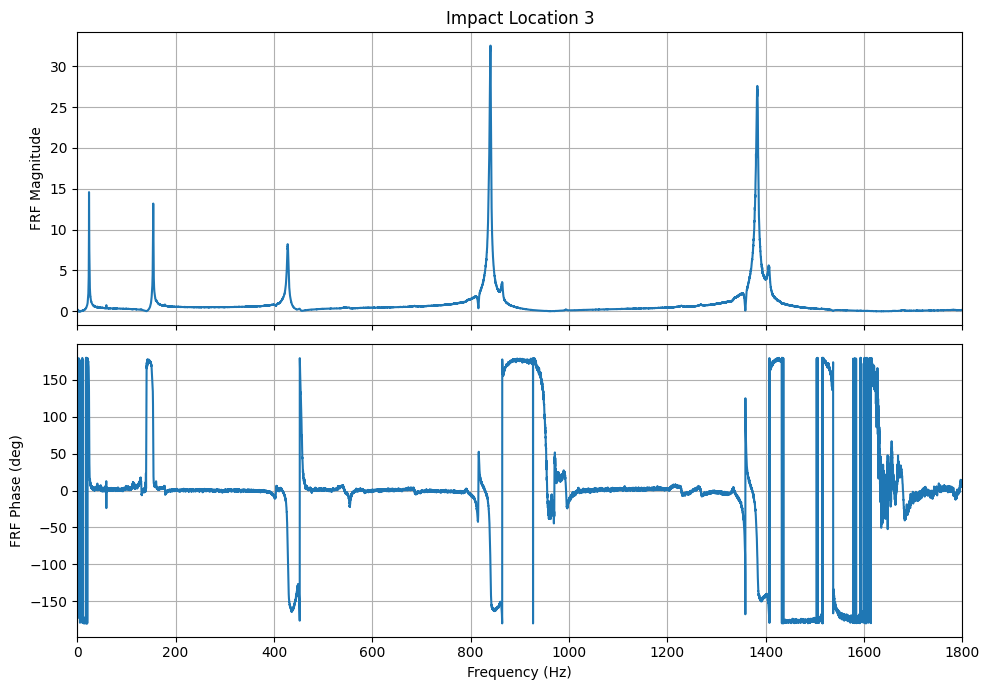

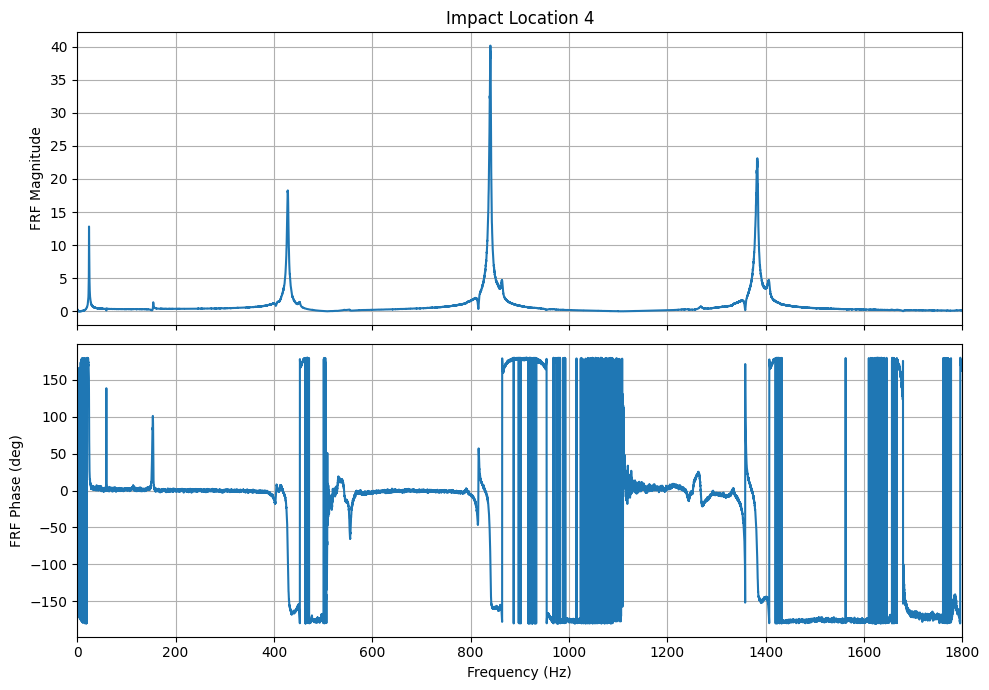

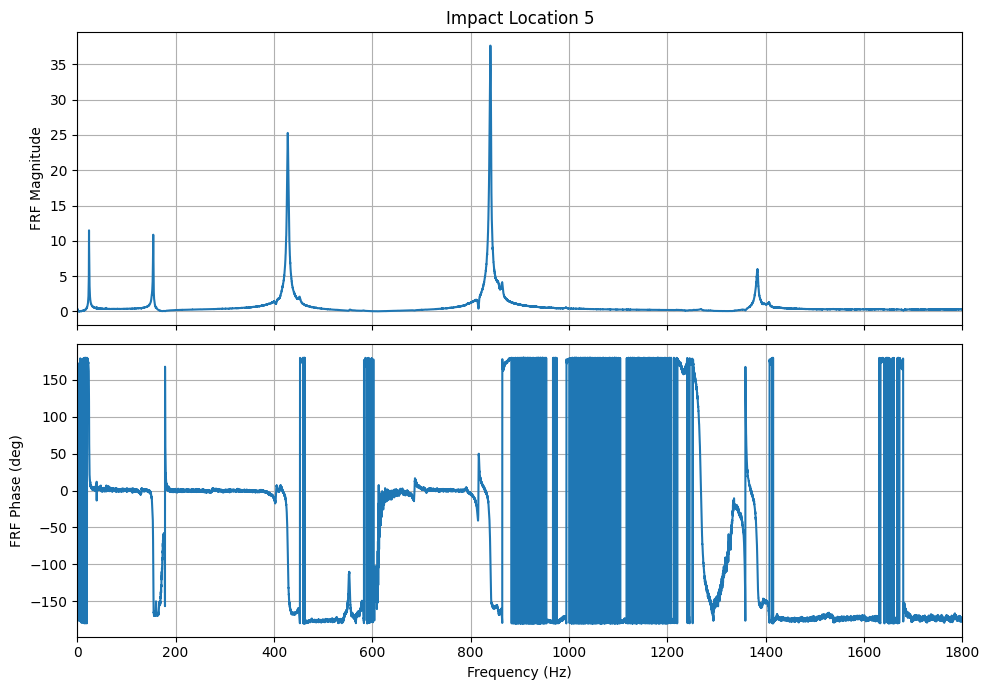

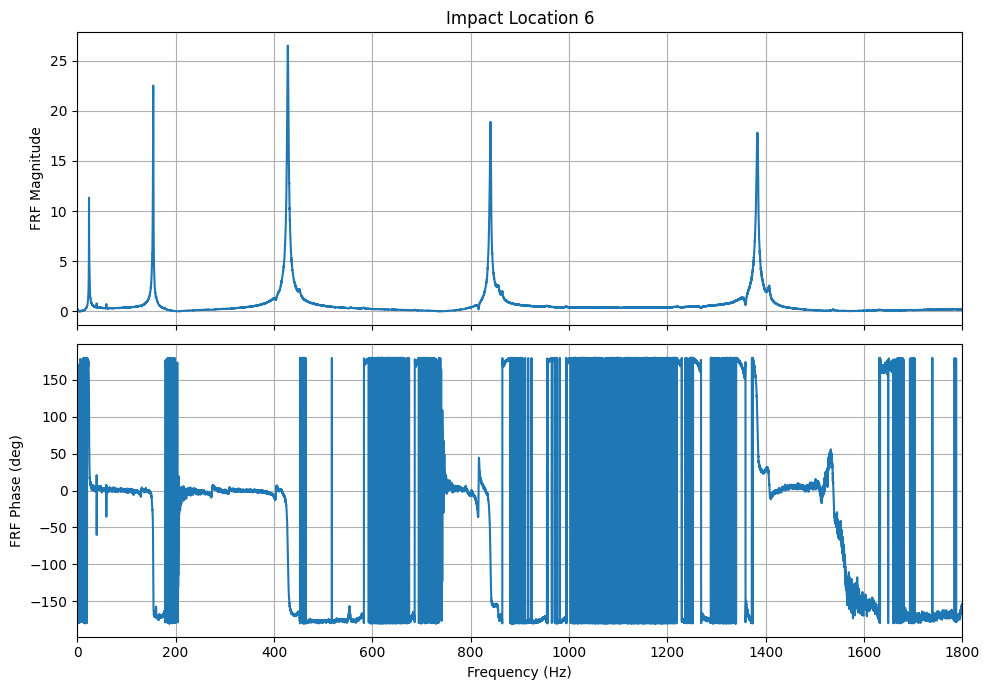

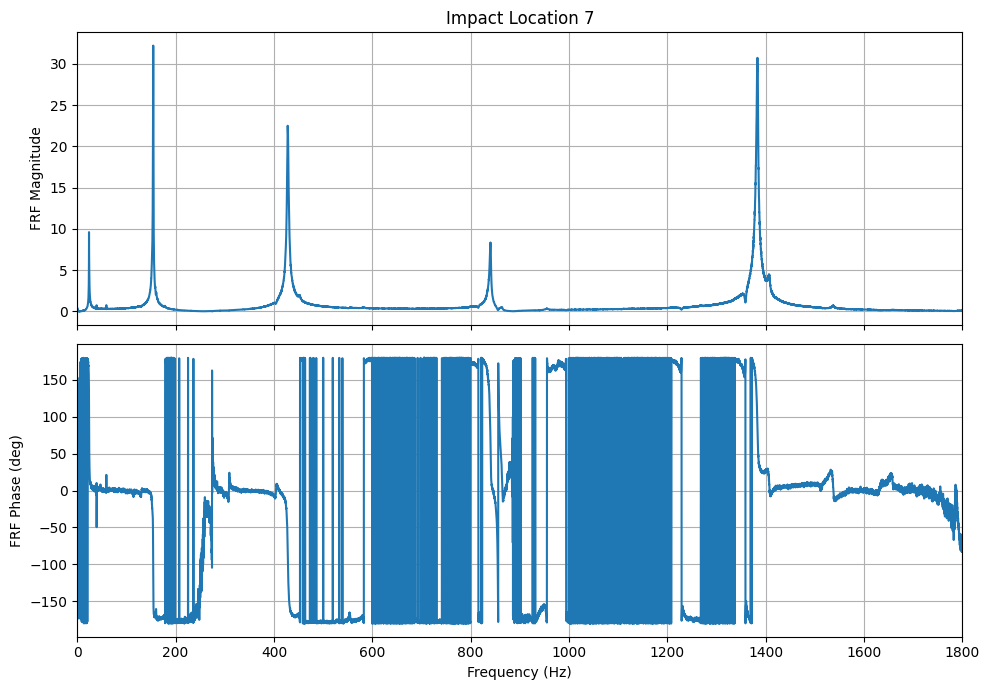

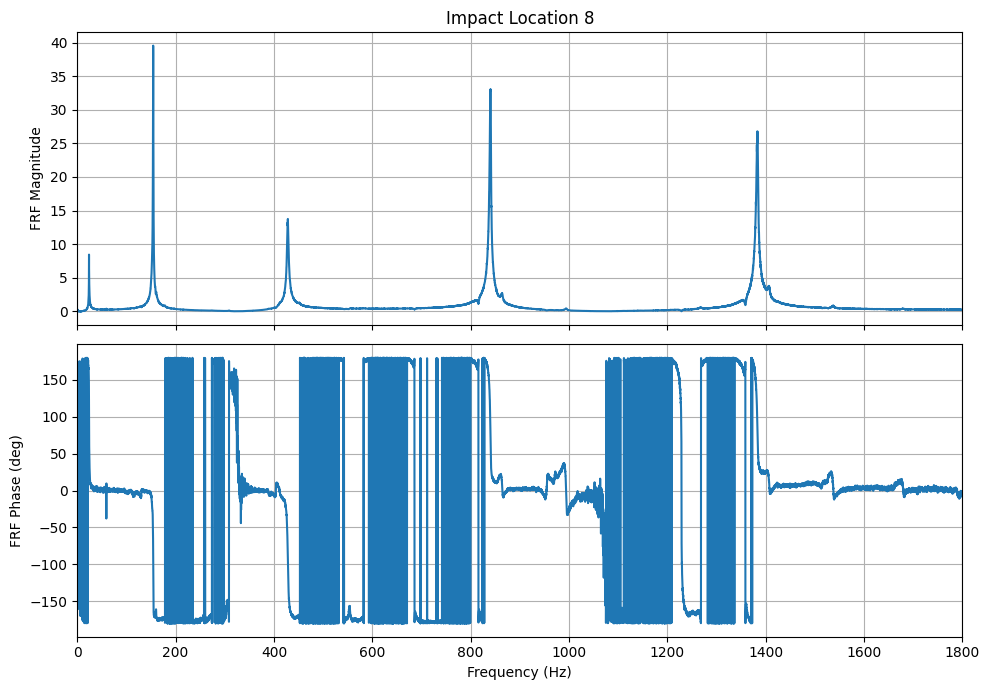

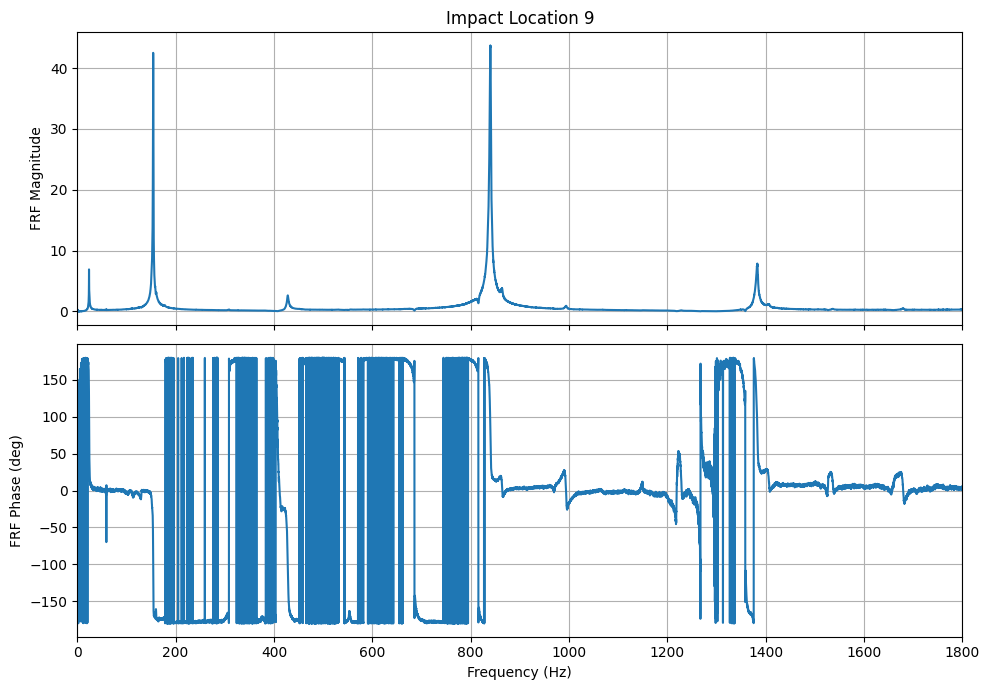

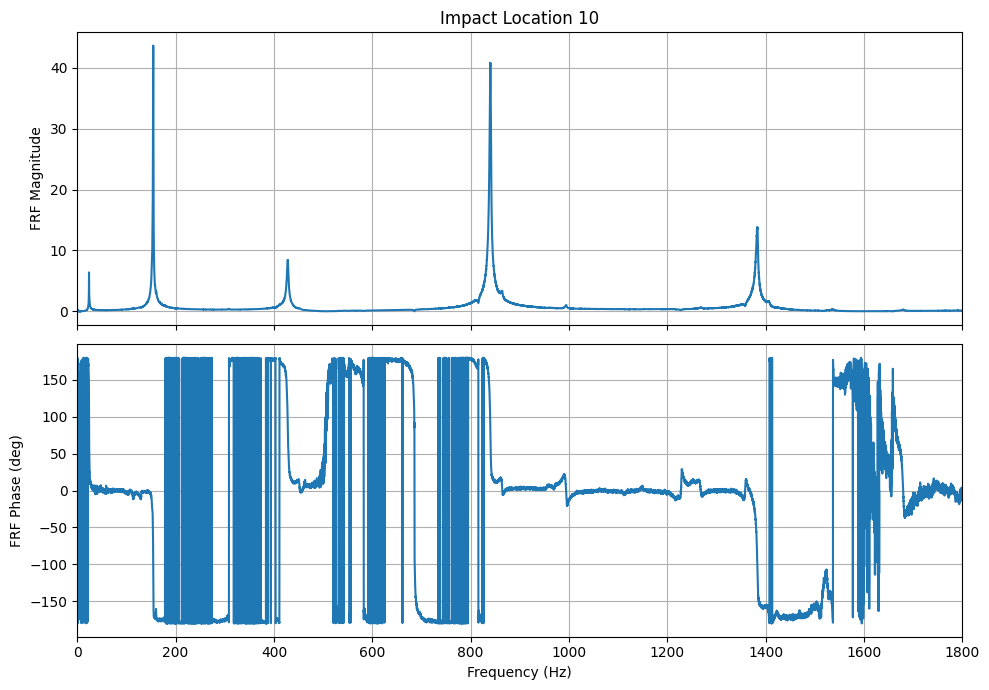

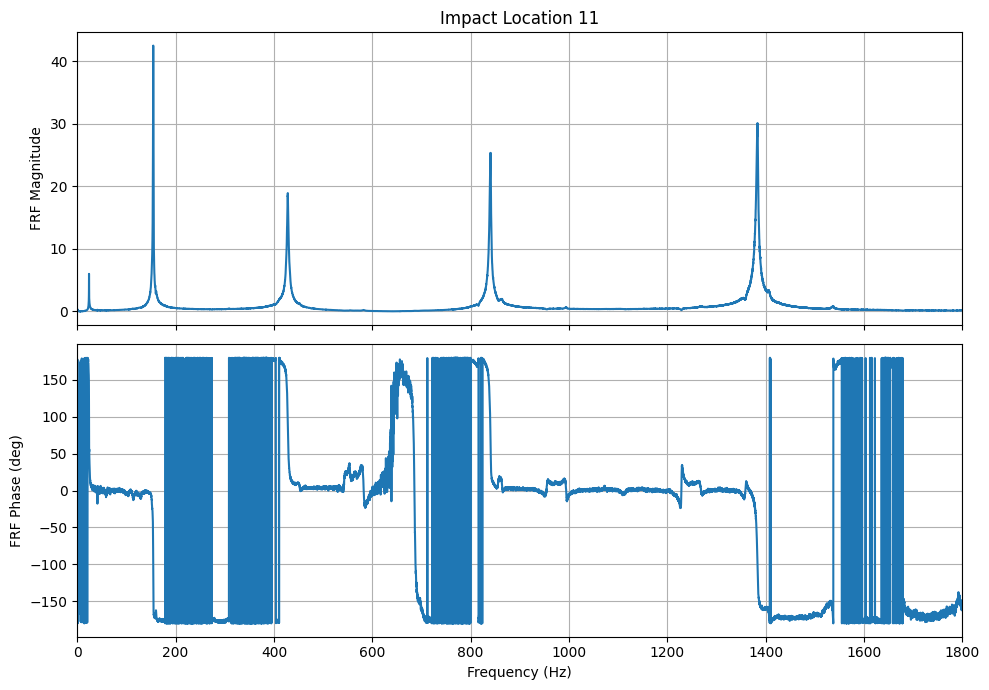

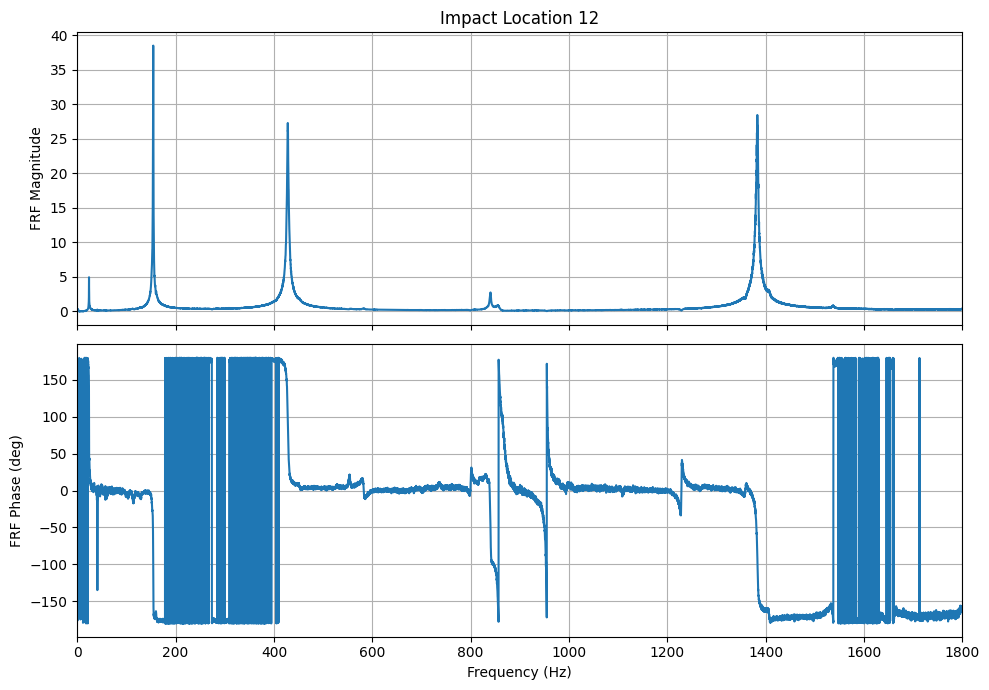

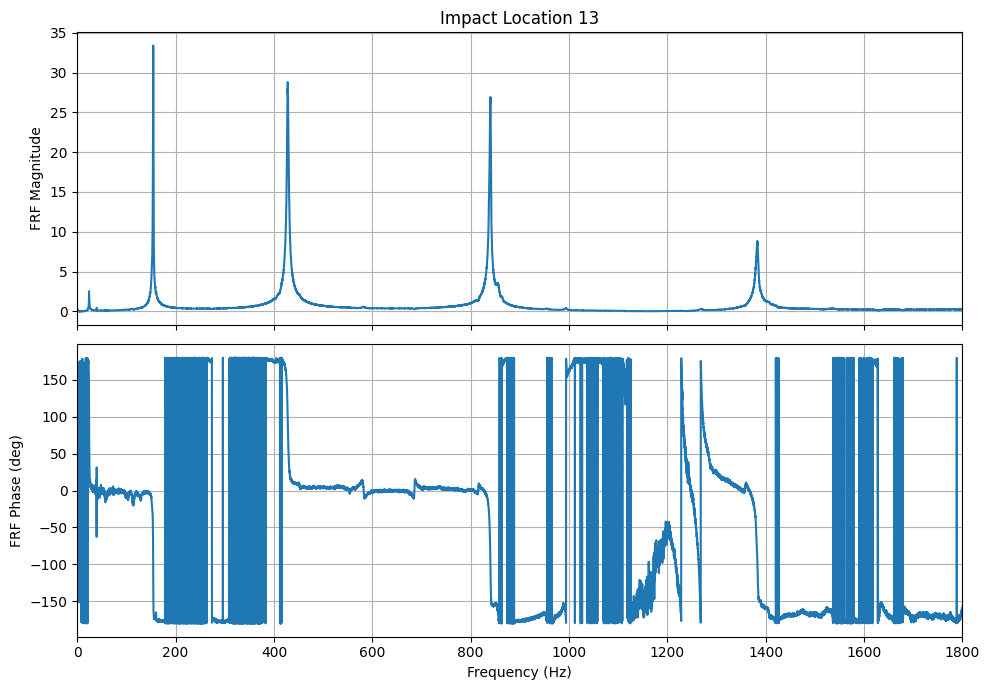

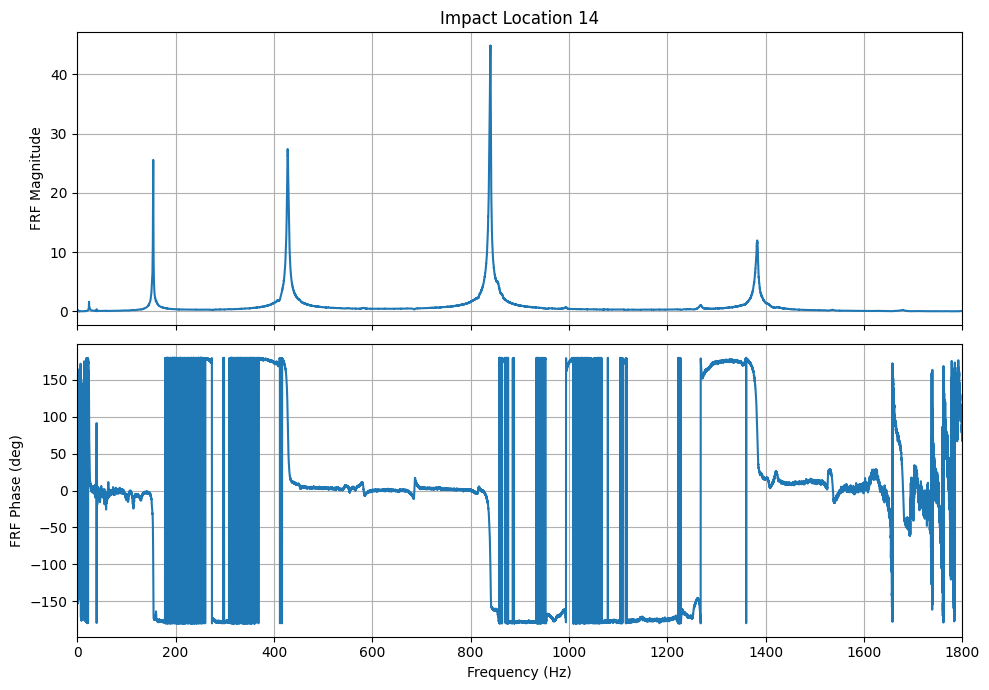

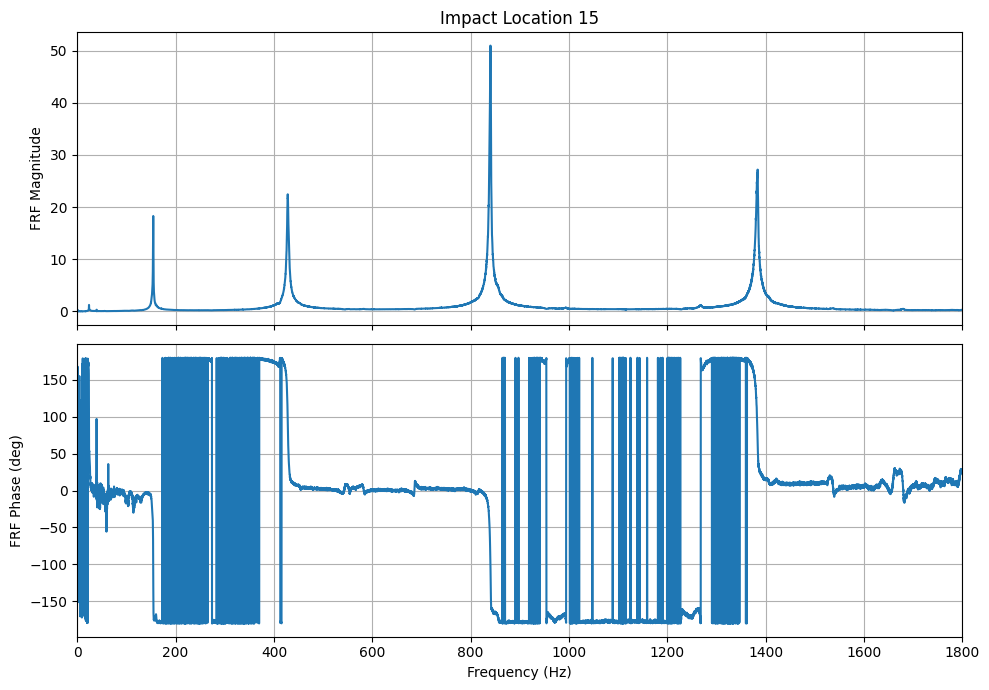

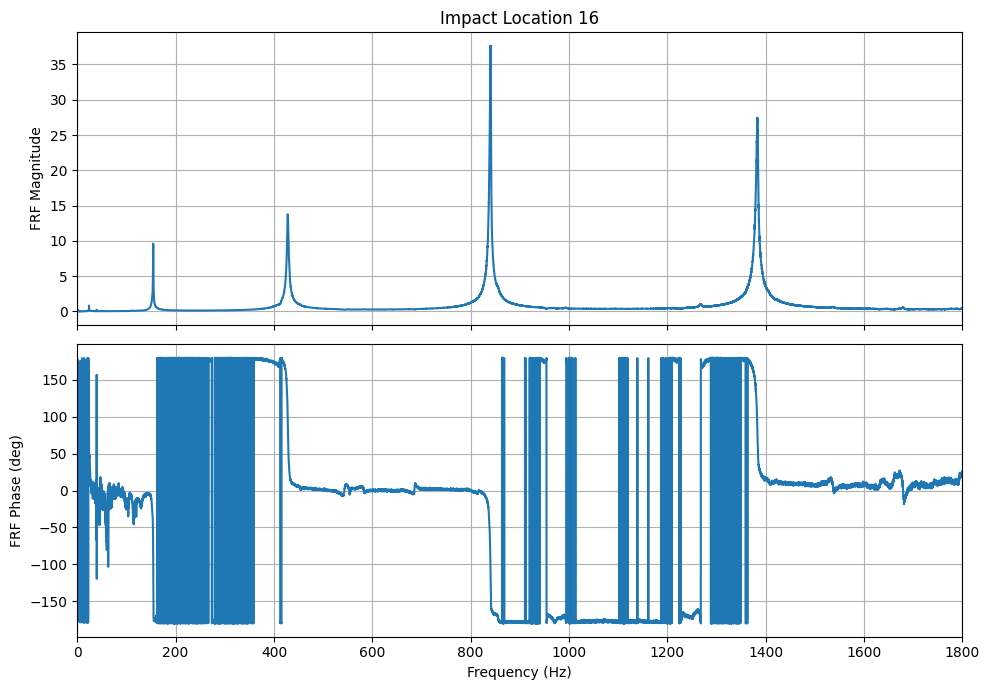

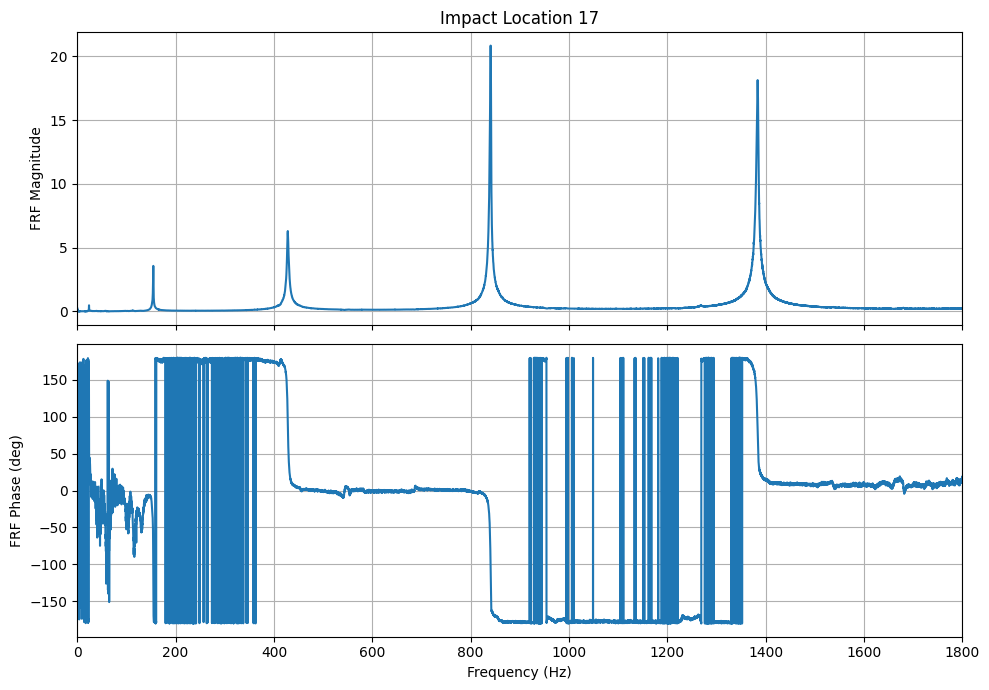

In [40]:
for i, d in enumerate(data, start=1):
    freq, mag, phase = restrict_band(d["freq_frf"], d["frf_mag"], d["frf_phase_deg"])

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(freq, mag)
    axes[0].set_ylabel("FRF Magnitude")
    axes[0].set_title(f"Impact Location {i}")

    axes[1].plot(freq, phase)
    axes[1].set_ylabel("FRF Phase (deg)")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_xlim(FREQ_MIN, FREQ_MAX)

    plt.tight_layout()
    plt.show()

In [34]:
def mag_peak_phase_table(d, min_peak_distance_hz=80, mag_prom_frac=0.03):
    freq, mag, phase = restrict_band(d["freq_frf"], d["frf_mag"], d["frf_phase_deg"])

    distance = hz_to_samples(freq, min_peak_distance_hz)
    prominence = np.max(mag) * mag_prom_frac
    peaks, _ = find_peaks(mag, prominence=prominence, distance=distance)

    df = pd.DataFrame({
        "frequency_hz": freq[peaks],
        "FRF_magnitude": mag[peaks],
        "phase_deg": phase[peaks]
    })

    return df

In [35]:
problem_1b_tables = []

for i, d in enumerate(data, start=1):
    df = mag_peak_phase_table(d)
    df.insert(0, "impact_location", i)
    df.insert(1, "file", d["file"])
    problem_1b_tables.append(df)

table_1b = pd.concat(problem_1b_tables, ignore_index=True)
table_1b

,impact_location,file,frequency_hz,FRF_magnitude,phase_deg
0,1,SIG0029.csv,23.875,18.085501,128.641285
1,1,SIG0029.csv,154.375,41.352942,80.235366
2,1,SIG0029.csv,428.250,23.575044,76.527712
3,1,SIG0029.csv,839.750,27.445667,76.999138
4,1,SIG0029.csv,1382.625,10.463043,84.101165
...,...,...,...,...,...
76,16,SIG0044.csv,1382.875,27.481194,87.986254
77,17,SIG0045.csv,154.625,3.564185,-124.894204
78,17,SIG0045.csv,428.125,6.297692,90.759361
79,17,SIG0045.csv,840.625,20.850020,-105.949354


In [36]:
table_1b.to_csv("problem_1b_mag_peaks_phase_table.csv", index=False)
print("Saved: problem_1b_mag_peaks_phase_table.csv")

Saved: problem_1b_mag_peaks_phase_table.csv


### 1c, 1d, 1e

In [37]:
# Representative frequencies from part (a)
freqs_a = np.sort(table_1a["frequency_hz"].dropna().unique())

# Representative frequencies from part (b)
freqs_b = np.sort(table_1b["frequency_hz"].dropna().unique())

print("Unique frequencies from 1(a):")
print(freqs_a)

print("\nUnique frequencies from 1(b):")
print(freqs_b)

Unique frequencies from 1(a):
[  23.875   24.     154.375  427.875  428.     428.125  428.25   839.875
  840.     840.625 1382.625 1382.75  1382.875 1383.    1383.125]

Unique frequencies from 1(b):
[  23.875  154.375  154.5    154.625  427.875  428.     428.125  428.25
  428.375  839.75   839.875  840.125  840.25   840.375  840.5    840.625
 1382.625 1382.75  1382.875 1383.    1383.125 1383.25  1383.375 1383.625]


In [38]:
def cluster_frequencies(freqs, tol_hz=25):
    freqs = np.sort(np.array(freqs, dtype=float))
    if len(freqs) == 0:
        return np.array([])

    clusters = [[freqs[0]]]
    for f in freqs[1:]:
        if abs(f - np.mean(clusters[-1])) <= tol_hz:
            clusters[-1].append(f)
        else:
            clusters.append([f])

    return np.array([np.median(c) for c in clusters])

clustered_a = cluster_frequencies(table_1a["frequency_hz"].dropna(), tol_hz=25)
clustered_b = cluster_frequencies(table_1b["frequency_hz"].dropna(), tol_hz=25)

print("Clustered frequencies from 1(a):", clustered_a)
print("Clustered frequencies from 1(b):", clustered_b)

Clustered frequencies from 1(a): [  24.      154.375   428.0625  839.9375 1382.875 ]
Clustered frequencies from 1(b): [  23.875  154.5    428.125  840.375 1383.   ]
